# 04 — Trip distribution: gravity models and IPF

Trip distribution answers: *given how many trips each zone produces and attracts,
which zone pairs do they travel between?* AequilibraE implements the two classic tools:

- **Synthetic gravity models** — trips between zones decay with impedance
  (travel time/cost), by a power, exponential or gamma deterrence function:
  $T_{ij} = a_i O_i \, b_j D_j \, f(c_{ij})$
- **IPF (iterative proportional fitting / Fratar / Furness)** — scales an existing
  *seed* matrix to match new row/column totals.

We calibrate gravity models against the observed Sioux Falls demand, then use IPF
to produce a balanced future-year matrix.


In [1]:
from pathlib import Path
from tempfile import gettempdir
from uuid import uuid4

import numpy as np

from aequilibrae.utils.create_example import create_example
from aequilibrae.paths import NetworkSkimming

np.random.seed(42)   # reproducible growth factors below

fldr = str(Path(gettempdir()) / uuid4().hex)
project = create_example(fldr, "sioux_falls")

# Build a free-flow time skim to use as impedance
project.network.build_graphs()
graph = project.network.graphs["c"]
graph.set_graph("free_flow_time")
graph.set_skimming(["free_flow_time"])
graph.set_blocked_centroid_flows(False)

skm = NetworkSkimming(graph)
skm.execute()
imped = skm.results.skims
imped.computational_view(["free_flow_time"])

C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)


C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)


C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)


C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)


C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)


C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)


                                                  :   0%|          | 0/24 [00:00<?, ?it/s]

In [2]:
# Observed demand
demand = project.matrices.get_matrix("demand_omx")
demand.computational_view(["matrix"])

# Intrazonal impedance: assume 75% of the nearest neighbour's cost
np.fill_diagonal(imped.matrix_view, 0)
intrazonals = 0.75 * np.amin(imped.matrix_view, where=imped.matrix_view > 0,
                             initial=imped.matrix_view.max(), axis=1)
np.fill_diagonal(imped.matrix_view, intrazonals)

## Calibrating deterrence functions

`GravityCalibration` finds the deterrence parameter that reproduces the observed
average trip length. We calibrate both a power and an exponential function and
compare the fit.


In [3]:
from aequilibrae.distribution import GravityCalibration

models = {}
for function in ["power", "expo"]:
    gc = GravityCalibration(matrix=demand, impedance=imped, function=function, nan_as_zero=True)
    gc.calibrate()
    models[function] = gc
    print(f"{function:5s}: calibrated -> {gc.report[-2].strip() if len(gc.report) > 1 else 'done'}")

power: calibrated -> Converged in 3  iterations to a global error of 2.886579864025407e-15


expo : calibrated -> Converged in 3  iterations to a global error of 4.440892098500626e-16


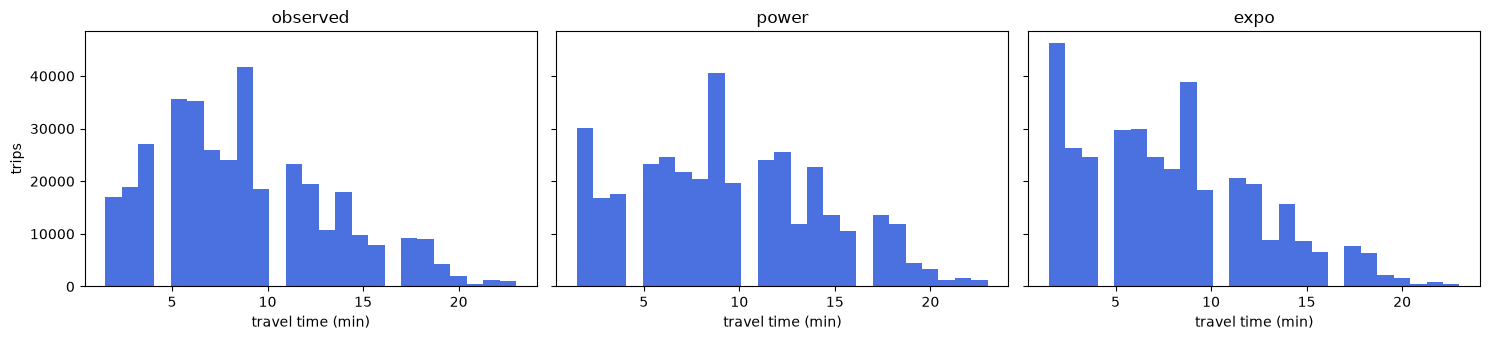

In [4]:
# Trip-length frequency distribution: observed vs modeled
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
datasets = [("observed", demand.matrix_view)] + [
    (name, gc.result_matrix.matrix_view) for name, gc in models.items()
]
for ax, (name, mat) in zip(axes, datasets):
    ax.hist(np.nan_to_num(imped.matrix_view.flatten(), 0), bins=25,
            weights=np.nan_to_num(mat.flatten()), color="#1d4ed8", alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("travel time (min)")
axes[0].set_ylabel("trips")
plt.tight_layout()

## Balancing a future matrix with IPF

Grow the current productions/attractions with (synthetic) growth factors, then let
IPF scale the seed matrix until both margins match.


In [5]:
import pandas as pd
from aequilibrae.distribution import Ipf

origins = np.sum(demand.matrix_view, axis=1)
destinations = np.sum(demand.matrix_view, axis=0)

orig = origins * (1 + np.random.rand(origins.shape[0]) / 10)       # up to +10%
dest = destinations * (1 + np.random.rand(origins.shape[0]) / 10)
dest *= orig.sum() / dest.sum()                                    # productions == attractions

vectors = pd.DataFrame({"origins": orig, "destinations": dest}, index=demand.index[:])

ipf = Ipf(matrix=demand, vectors=vectors, row_field="origins",
          column_field="destinations", nan_as_zero=True)
ipf.fit()

print(f"converged in {len(ipf.report)} report lines; total trips {ipf.output.matrix_view.sum():,.0f}")
ipf.save_to_project(name="demand_future", file_name="demand_future.omx")

converged in 13 report lines; total trips 375,665


In [6]:
project.close()

---
**Next:** [05 — Traffic assignment](05_traffic_assignment.ipynb): loading the demand onto
the network under congested equilibrium.
